reference
- https://github.com/huggingface/transformers/blob/master/src/transformers/modeling_albert.py
- https://github.com/google-research/ALBERT/blob/master/modeling.py

In [ ]:
def get_num_params(model):
    n_params = 0
    for param in model.parameters():
        param_shape = list(param.shape)
        n_params += reduce(lambda x, y: x*y, param_shape)
    return n_params

In [ ]:
class Config():
    def __init__(self):
        '''
            this configuration follows ALBERT `base`.
        '''
        self.n_embbed = 20 # E. originally 128
        self.n_vocab = 10  # V. originally 32000
        self.n_hidden = 40 # H. originally 768
        self.n_hidden_ff = self.n_hidden * 4 # 4H. originally n_hidden * 4
        self.n_maxseq = 15 # originally 512
        self.dropout_rate = 0.1
        self.eps = 1e-6
        self.n_layers = 6       # originally 12
        self.n_head = 8         # originally H/64, originally H/64
        assert self.n_hidden % self.n_head == 0
        self.attention_size = self.n_hidden // self.n_head

In [ ]:
# class Config():
#     def __init__(self):
#         '''
#             this configuration follows ALBERT `base`.
#         '''
#         self.n_embbed = 128
#         self.n_vocab = 32000
#         self.n_hidden = 768
#         self.n_hidden_ff = self.n_hidden * 4 # 4H. originally n_hidden * 4
#         self.n_maxseq = 512
#         self.dropout_rate = 0.1
#         self.eps = 1e-6
#         self.n_layers = 12
#         self.n_head = self.n_hidden//64
#         assert self.n_hidden % self.n_head == 0
#         self.attention_size = self.n_hidden // self.n_head

In [ ]:
conf = Config()

In [ ]:
tmp = torch.rand((conf.n_maxseq, conf.n_embbed))
tmp.shape, tmp[1:5].shape
tmp[1:5].shape

In [ ]:
# class LayerNorm(nn.Module):
#     def __init__(self, conf, eps=1e-6):
#         super().__init__()
#         self.gamma = nn.Parameter(torch.ones(conf.n_embbed))
#         self.beta = nn.Parameter(torch.zeros(conf.n_embbed))
#         self.eps = eps
#     def forward(self, x):
#         u = x.mean(-1, keepdim=True)
#         s = (x - u).pow(2).mean(-1, keepdim=True)
#         x = (x - u) / torch.sqrt(s + self.eps)
#         return self.gamma * x + self.beta

In [ ]:
class ContextDependentEmbedding(nn.Module):
    def __init__(self, conf, use_positinal_embedding=True):
        super().__init__()
        # context-independent embedding
        self.embedded_word = nn.Embedding(conf.n_vocab, conf.n_embbed)
        
        # FIXME: n_embbed -> n_embed
        self.pos_emb_vector = nn.Embedding(conf.n_maxseq, conf.n_embbed)
        self.use_positinal_embedding = use_positinal_embedding
        self.norm = nn.LayerNorm(conf.n_embbed, eps=conf.eps)
        self.drop = nn.Dropout(conf.dropout_rate)
        
    def forward(self, x):
        n_seq = x.size()[1]
        ci_emb = self.embedded_word(x)
        
        if self.use_positinal_embedding:
            cd_emb = ci_emb + self.pos_emb_vector.weight[:n_seq]
            cd_emb = self.drop(self.norm(cd_emb))
        return cd_emb

In [ ]:
class AlbertMultiHeadAttention(nn.Module):
    def __init__(self, conf):
        super().__init__()
        torch.manual_seed(7)
        
        self.query = nn.Linear(conf.n_hidden, conf.n_hidden)
        self.key = nn.Linear(conf.n_hidden, conf.n_hidden)
        self.value = nn.Linear(conf.n_hidden, conf.n_hidden)
        self.attention_size = conf.attention_size
        self.hidden_size = conf.n_hidden
        self.n_head = conf.n_head
        self.softmax = torch.nn.Softmax(dim=-1)
        self.layer_norm = nn.LayerNorm(conf.n_hidden, eps=conf.eps)
        
        #torch.manual_seed(7)
        #self.dense = nn.Linear(conf.n_hidden, conf.n_hidden)
        
        torch.manual_seed(7)
        self.dense = nn.Linear(conf.n_hidden, conf.n_hidden)
        self.attention_head_size = conf.n_hidden // conf.n_head
        
    def split_tensor(self, x):
        x_split = torch.split(x, self.attention_size, dim=2)
        return torch.stack(x_split, dim=-2)
        
    #def merge_tensor(self, x):
    #    s = x.size()[-2]
    #    return torch.cat([x[:,:,i,:] for i in range(s)], dim=-1)
    
    def merge_last_ndims(self, x, n_dims):
        s = x.size()
        return x.view(*s[:-n_dims], -1)
    
    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        q, k, v = list(map(lambda x: self.split_tensor(x).transpose(1,2), [q, k, v]))

        score = (q @ k.transpose(-2,-1)) / np.sqrt(self.attention_size)
        prob = self.softmax(score)
        
        # FIXME: why contiguous?
        context = (prob @ v).transpose(1,2).contiguous()
        #w = (
        #    self.dense.weight.t()
        #    .view(self.n_head, self.attention_head_size, self.hidden_size)
        #    .to(context.dtype)
        #)
        #b = self.dense.bias.to(context.dtype)
        #projected_context = torch.einsum("bfnd,ndh->bfh", context, w) + b
        projected_context = self.dense(self.merge_last_ndims(context, 2))
        #print(projected_context.sum())
        
        # do something about `mask`
        hidden = self.layer_norm(x + projected_context)
        return hidden

In [ ]:
# %%time

# for _ in range(10000):
#     o1 = att(inp)

In [ ]:
def gelu_new(x):
    """ Implementation of the gelu activation function currently in Google Bert repo (identical to OpenAI GPT).
        Also see https://arxiv.org/abs/1606.08415
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

In [ ]:
class AlbertLayer(nn.Module):
    def __init__(self, conf):
        super().__init__()
        self.mhead_attention = AlbertMultiHeadAttention(conf)
        self.n_hidden = conf.n_hidden
        self.n_hidden_ff = conf.n_hidden_ff
        self.feedforward = nn.Linear(conf.n_hidden, conf.n_hidden_ff)
        self.feedforward_out = nn.Linear(conf.n_hidden_ff, conf.n_hidden)
        self.layer_norm = nn.LayerNorm(conf.n_hidden, eps=conf.eps)
        self.act_fn = gelu_new
        
    def forward(self, x):
        x = self.mhead_attention(x)
        x = self.layer_norm(
            self.feedforward_out(self.act_fn(self.feedforward(x))) + x
        )
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, conf):
        super().__init__()
        self.linear_to_hidden = nn.Linear(conf.n_embbed, conf.n_hidden)
        self.n_layers = conf.n_layers
        layer = AlbertLayer(conf)
        self.layers = nn.ModuleList([layer for _ in range(self.n_layers)])
        
    def forward(self, x):
        x = self.linear_to_hidden(x)
        for layer in self.layers:
            x = layer(x)

        return x

In [ ]:
class AlbertModel(nn.Module):
    def __init__(self, conf):
        super().__init__()
        self.embedding = ContextDependentEmbedding(conf, use_positinal_embedding=True)
        self.encoder = Transformer(conf)
        self.pooler = nn.Linear(conf.n_hidden, conf.n_hidden)
        self.pooler_activation = nn.Tanh()
        
    def forward(self, x):
        x = self.embedding(x)
        x = self.encoder(x)
        x = self.pooler_activation(self.pooler(x))
        return x

In [ ]:
np.random.seed(102)
n_batch = 3
inp = np.random.randint(0, conf.n_vocab, (n_batch, 10))
inp[:,0] = 1
inp[:,-3:] = 0
inp = torch.LongTensor(inp)
inp

In [ ]:
model = AlbertModel(conf)

In [ ]:
model(inp).shape

In [ ]:
%%time
for _ in range(100):
    model(inp)

In [ ]:
get_num_params(model)

#### 낙서장

In [ ]:
import sys
sys.path.insert(0, '/anything/git/jinkilee.github.io/code/python/ai/albert')

In [ ]:
import torch
import numpy as np
from torch import nn
from transformers.modeling_bert import ACT2FN, BertEmbeddings, BertSelfAttention, prune_linear_layer
import math
from utils import set_seeds

In [ ]:
from config import Config
from transformers.configuration_albert import AlbertConfig
myconf = Config()

In [ ]:
conf = AlbertConfig(
    embedding_size=myconf.n_embbed,
    vocab_size=myconf.n_vocab,
    hidden_size=myconf.n_hidden,            # H
    intermediate_size=myconf.n_hidden_ff,   # 4H
    max_position_embeddings=myconf.n_maxseq,
    layer_norm_eps=myconf.eps,
    num_hidden_layers=myconf.n_layers,
    num_attention_heads=myconf.n_head,
)

In [ ]:
BertLayerNorm = torch.nn.LayerNorm
class BertEmbeddings(nn.Module):
    """Construct the embeddings from word, position and token_type embeddings.
    """

    def __init__(self, config):
        super().__init__()
        torch.manual_seed(10)
        
        self.word_embeddings = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=0)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)

        # self.LayerNorm is not snake-cased to stick with TensorFlow model variable name and be able to load
        # any TensorFlow checkpoint file
        self.LayerNorm = BertLayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, input_ids=None, token_type_ids=None, position_ids=None, inputs_embeds=None):
        if input_ids is not None:
            input_shape = input_ids.size()
        else:
            input_shape = inputs_embeds.size()[:-1]

        seq_length = input_shape[1]
        device = input_ids.device if input_ids is not None else inputs_embeds.device
        if position_ids is None:
            position_ids = torch.arange(seq_length, dtype=torch.long, device=device)
            position_ids = position_ids.unsqueeze(0).expand(input_shape)
        if token_type_ids is None:
            token_type_ids = torch.zeros(input_shape, dtype=torch.long, device=device)

        print('input: {:.4f}'.format(input_ids.sum()))
        print('pos: {:.4f}'.format(position_ids.sum()))
        print('tok: {:.4f}'.format(token_type_ids.sum()))
        print('---------------')
        if inputs_embeds is None:
            inputs_embeds = self.word_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)
        token_type_embeddings = self.token_type_embeddings(token_type_ids)

        print('inputs_embed: {:.4f}'.format(inputs_embeds.sum()))
        print('position_embeddings: {:.4f}'.format(position_embeddings.sum()))
        print('token_type_embeddings: {:.4f}'.format(token_type_embeddings.sum()))
        print('---------------')
                
        print('word_weight: {:.4f} {}'.format(self.word_embeddings.weight.sum(), self.word_embeddings.weight.shape))
        print('pos_weight: {:.4f} {}'.format(self.position_embeddings.weight.sum(), self.position_embeddings.weight.shape))
        print('tok_weight: {:.4f} {}'.format(self.token_type_embeddings.weight.sum(), self.token_type_embeddings.weight.shape))
        embeddings = inputs_embeds + position_embeddings + token_type_embeddings
        print('embedding: {}'.format(embeddings.shape))
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings


In [ ]:
class AlbertEmbeddings(BertEmbeddings):
    """
    Construct the embeddings from word, position and token_type embeddings.
    """

    def __init__(self, config):
        super().__init__(config)
        torch.manual_seed(10)
        
        np.random.seed(10)
        
        self.word_embeddings = nn.Embedding(config.vocab_size, config.embedding_size, padding_idx=0)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.embedding_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.embedding_size)
        self.LayerNorm = torch.nn.LayerNorm(config.embedding_size, eps=config.layer_norm_eps)

In [ ]:
class BertSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        torch.manual_seed(10)
        
        if config.hidden_size % config.num_attention_heads != 0:
            raise ValueError(
                "The hidden size (%d) is not a multiple of the number of attention "
                "heads (%d)" % (config.hidden_size, config.num_attention_heads)
            )
        self.output_attentions = config.output_attentions

        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = int(config.hidden_size / config.num_attention_heads)
        self.all_head_size = self.num_attention_heads * self.attention_head_size

        self.query = nn.Linear(config.hidden_size, self.all_head_size)
        self.key = nn.Linear(config.hidden_size, self.all_head_size)
        self.value = nn.Linear(config.hidden_size, self.all_head_size)

        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)

    def transpose_for_scores(self, x):
        new_x_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        x = x.view(*new_x_shape)
        return x.permute(0, 2, 1, 3)

    def forward(
        self,
        hidden_states,
        attention_mask=None,
        head_mask=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
    ):
        mixed_query_layer = self.query(hidden_states)

        # If this is instantiated as a cross-attention module, the keys
        # and values come from an encoder; the attention mask needs to be
        # such that the encoder's padding tokens are not attended to.
        if encoder_hidden_states is not None:
            mixed_key_layer = self.key(encoder_hidden_states)
            mixed_value_layer = self.value(encoder_hidden_states)
            attention_mask = encoder_attention_mask
        else:
            mixed_key_layer = self.key(hidden_states)
            mixed_value_layer = self.value(hidden_states)

        query_layer = self.transpose_for_scores(mixed_query_layer)
        key_layer = self.transpose_for_scores(mixed_key_layer)
        value_layer = self.transpose_for_scores(mixed_value_layer)

        # Take the dot product between "query" and "key" to get the raw attention scores.
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)
        if attention_mask is not None:
            # Apply the attention mask is (precomputed for all layers in BertModel forward() function)
            attention_scores = attention_scores + attention_mask

        # Normalize the attention scores to probabilities.
        attention_probs = nn.Softmax(dim=-1)(attention_scores)

        # This is actually dropping out entire tokens to attend to, which might
        # seem a bit unusual, but is taken from the original Transformer paper.
        attention_probs = self.dropout(attention_probs)

        # Mask heads if we want to
        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        context_layer = torch.matmul(attention_probs, value_layer)

        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        new_context_layer_shape = context_layer.size()[:-2] + (self.all_head_size,)
        context_layer = context_layer.view(*new_context_layer_shape)

        outputs = (context_layer, attention_probs) if self.output_attentions else (context_layer,)
        return outputs

In [ ]:
class AlbertAttention(BertSelfAttention):
    def __init__(self, config):
        super().__init__(config)
        torch.manual_seed(10)
        
        self.output_attentions = config.output_attentions
        self.num_attention_heads = config.num_attention_heads
        self.hidden_size = config.hidden_size
        self.attention_head_size = config.hidden_size // config.num_attention_heads
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)
        
        torch.manual_seed(10)
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.pruned_heads = set()

    def prune_heads(self, heads):
        if len(heads) == 0:
            return
        mask = torch.ones(self.num_attention_heads, self.attention_head_size)
        heads = set(heads) - self.pruned_heads  # Convert to set and emove already pruned heads
        for head in heads:
            # Compute how many pruned heads are before the head and move the index accordingly
            head = head - sum(1 if h < head else 0 for h in self.pruned_heads)
            mask[head] = 0
        mask = mask.view(-1).contiguous().eq(1)
        index = torch.arange(len(mask))[mask].long()

        # Prune linear layers
        self.query = prune_linear_layer(self.query, index)
        self.key = prune_linear_layer(self.key, index)
        self.value = prune_linear_layer(self.value, index)
        self.dense = prune_linear_layer(self.dense, index, dim=1)

        # Update hyper params and store pruned heads
        self.num_attention_heads = self.num_attention_heads - len(heads)
        self.all_head_size = self.attention_head_size * self.num_attention_heads
        self.pruned_heads = self.pruned_heads.union(heads)

    def forward(self, input_ids, attention_mask=None, head_mask=None):
        mixed_query_layer = self.query(input_ids)
        mixed_key_layer = self.key(input_ids)
        mixed_value_layer = self.value(input_ids)

        query_layer = self.transpose_for_scores(mixed_query_layer)
        key_layer = self.transpose_for_scores(mixed_key_layer)
        value_layer = self.transpose_for_scores(mixed_value_layer)

        # Take the dot product between "query" and "key" to get the raw attention scores.
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)
        if attention_mask is not None:
            print(attention_scores.shape, attention_mask.shape)
            # Apply the attention mask is (precomputed for all layers in BertModel forward() function)
            attention_scores = attention_scores + attention_mask

        # Normalize the attention scores to probabilities.
        attention_probs = nn.Softmax(dim=-1)(attention_scores)

        # This is actually dropping out entire tokens to attend to, which might
        # seem a bit unusual, but is taken from the original Transformer paper.
        attention_probs = self.dropout(attention_probs)

        # Mask heads if we want to
        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        context_layer = torch.matmul(attention_probs, value_layer)

        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()

        # Should find a better way to do this
        w = (
            self.dense.weight.t()
            .view(self.num_attention_heads, self.attention_head_size, self.hidden_size)
            .to(context_layer.dtype)
        )
        b = self.dense.bias.to(context_layer.dtype)

        projected_context_layer = torch.einsum("bfnd,ndh->bfh", context_layer, w) + b
        projected_context_layer_dropout = self.dropout(projected_context_layer)
        layernormed_context_layer = self.LayerNorm(input_ids + projected_context_layer_dropout)
        return (layernormed_context_layer, attention_probs) if self.output_attentions else (layernormed_context_layer,)


In [ ]:
class AlbertLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        torch.manual_seed(10)
        
        self.config = config
        self.full_layer_layer_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.attention = AlbertAttention(config)
        self.ffn = nn.Linear(config.hidden_size, config.intermediate_size)
        self.ffn_output = nn.Linear(config.intermediate_size, config.hidden_size)
        self.activation = ACT2FN[config.hidden_act]

    def forward(self, hidden_states, attention_mask=None, head_mask=None):
        attention_output = self.attention(hidden_states, attention_mask, head_mask)
        ffn_output = self.ffn(attention_output[0])
        ffn_output = self.activation(ffn_output)
        ffn_output = self.ffn_output(ffn_output)
        hidden_states = self.full_layer_layer_norm(ffn_output + attention_output[0])

        return (hidden_states,) + attention_output[1:]  # add attentions if we output them

In [ ]:
class AlbertLayerGroup(nn.Module):
    def __init__(self, config):
        super().__init__()
        torch.manual_seed(10)
        
        self.output_attentions = config.output_attentions
        self.output_hidden_states = config.output_hidden_states
        self.albert_layers = nn.ModuleList([AlbertLayer(config) for _ in range(config.inner_group_num)])

    def forward(self, hidden_states, attention_mask=None, head_mask=None):
        layer_hidden_states = ()
        layer_attentions = ()

        for layer_index, albert_layer in enumerate(self.albert_layers):
            if head_mask:
                hmask = head_mask[layer_index]
            else:
                hmask = None
            layer_output = albert_layer(hidden_states, attention_mask, None)
            hidden_states = layer_output[0]

            if self.output_attentions:
                layer_attentions = layer_attentions + (layer_output[1],)

            if self.output_hidden_states:
                layer_hidden_states = layer_hidden_states + (hidden_states,)

        outputs = (hidden_states,)
        if self.output_hidden_states:
            outputs = outputs + (layer_hidden_states,)
        if self.output_attentions:
            outputs = outputs + (layer_attentions,)
        return outputs  # last-layer hidden state, (layer hidden states), (layer attentions)

In [ ]:
class AlbertTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        torch.manual_seed(10)
        
        self.config = config
        self.output_attentions = config.output_attentions
        self.output_hidden_states = config.output_hidden_states
        self.embedding_hidden_mapping_in = nn.Linear(config.embedding_size, config.hidden_size)
        self.albert_layer_groups = nn.ModuleList([AlbertLayerGroup(config) for _ in range(config.num_hidden_groups)])

    def forward(self, hidden_states, attention_mask=None, head_mask=None):
        hidden_states = self.embedding_hidden_mapping_in(hidden_states)

        all_attentions = ()

        if self.output_hidden_states:
            all_hidden_states = (hidden_states,)

        for i in range(self.config.num_hidden_layers):
            # Number of layers in a hidden group
            layers_per_group = int(self.config.num_hidden_layers / self.config.num_hidden_groups)

            # Index of the hidden group
            group_idx = int(i / (self.config.num_hidden_layers / self.config.num_hidden_groups))

            if head_mask:
                hmask = head_mask[group_idx * layers_per_group : (group_idx + 1) * layers_per_group]
            else:
                hmask = None
            
            layer_group_output = self.albert_layer_groups[group_idx](
                hidden_states,
                attention_mask,
                hmask,
            )
            print(i, layer_group_output[0].shape, layer_group_output[0].sum())
            hidden_states = layer_group_output[0]

            if self.output_attentions:
                all_attentions = all_attentions + layer_group_output[-1]

            if self.output_hidden_states:
                all_hidden_states = all_hidden_states + (hidden_states,)

        outputs = (hidden_states,)
        if self.output_hidden_states:
            outputs = outputs + (all_hidden_states,)
        if self.output_attentions:
            outputs = outputs + (all_attentions,)
        return outputs  # last-layer hidden state, (all hidden states), (all attentions)

In [ ]:
from transformers.modeling_utils import PreTrainedModel

ALBERT_PRETRAINED_MODEL_ARCHIVE_MAP = {
    "albert-base-v1": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-base-pytorch_model.bin",
    "albert-large-v1": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-large-pytorch_model.bin",
    "albert-xlarge-v1": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-xlarge-pytorch_model.bin",
    "albert-xxlarge-v1": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-xxlarge-pytorch_model.bin",
    "albert-base-v2": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-base-v2-pytorch_model.bin",
    "albert-large-v2": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-large-v2-pytorch_model.bin",
    "albert-xlarge-v2": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-xlarge-v2-pytorch_model.bin",
    "albert-xxlarge-v2": "https://s3.amazonaws.com/models.huggingface.co/bert/albert-xxlarge-v2-pytorch_model.bin",
}

def load_tf_weights_in_albert(model, config, tf_checkpoint_path):
    """ Load tf checkpoints in a pytorch model."""
    try:
        import re
        import numpy as np
        import tensorflow as tf
    except ImportError:
        logger.error(
            "Loading a TensorFlow model in PyTorch, requires TensorFlow to be installed. Please see "
            "https://www.tensorflow.org/install/ for installation instructions."
        )
        raise
    tf_path = os.path.abspath(tf_checkpoint_path)
    logger.info("Converting TensorFlow checkpoint from {}".format(tf_path))
    # Load weights from TF model
    init_vars = tf.train.list_variables(tf_path)
    names = []
    arrays = []
    for name, shape in init_vars:
        logger.info("Loading TF weight {} with shape {}".format(name, shape))
        array = tf.train.load_variable(tf_path, name)
        names.append(name)
        arrays.append(array)

    for name, array in zip(names, arrays):
        print(name)

    for name, array in zip(names, arrays):
        original_name = name

        # If saved from the TF HUB module
        name = name.replace("module/", "")

        # Renaming and simplifying
        name = name.replace("ffn_1", "ffn")
        name = name.replace("bert/", "albert/")
        name = name.replace("attention_1", "attention")
        name = name.replace("transform/", "")
        name = name.replace("LayerNorm_1", "full_layer_layer_norm")
        name = name.replace("LayerNorm", "attention/LayerNorm")
        name = name.replace("transformer/", "")

        # The feed forward layer had an 'intermediate' step which has been abstracted away
        name = name.replace("intermediate/dense/", "")
        name = name.replace("ffn/intermediate/output/dense/", "ffn_output/")

        # ALBERT attention was split between self and output which have been abstracted away
        name = name.replace("/output/", "/")
        name = name.replace("/self/", "/")

        # The pooler is a linear layer
        name = name.replace("pooler/dense", "pooler")

        # The classifier was simplified to predictions from cls/predictions
        name = name.replace("cls/predictions", "predictions")
        name = name.replace("predictions/attention", "predictions")

        # Naming was changed to be more explicit
        name = name.replace("embeddings/attention", "embeddings")
        name = name.replace("inner_group_", "albert_layers/")
        name = name.replace("group_", "albert_layer_groups/")

        # Classifier
        if len(name.split("/")) == 1 and ("output_bias" in name or "output_weights" in name):
            name = "classifier/" + name

        # No ALBERT model currently handles the next sentence prediction task
        if "seq_relationship" in name:
            continue

        name = name.split("/")

        # Ignore the gradients applied by the LAMB/ADAM optimizers.
        if "adam_m" in name or "adam_v" in name or "global_step" in name:
            logger.info("Skipping {}".format("/".join(name)))
            continue

        pointer = model
        for m_name in name:
            if re.fullmatch(r"[A-Za-z]+_\d+", m_name):
                scope_names = re.split(r"_(\d+)", m_name)
            else:
                scope_names = [m_name]

            if scope_names[0] == "kernel" or scope_names[0] == "gamma":
                pointer = getattr(pointer, "weight")
            elif scope_names[0] == "output_bias" or scope_names[0] == "beta":
                pointer = getattr(pointer, "bias")
            elif scope_names[0] == "output_weights":
                pointer = getattr(pointer, "weight")
            elif scope_names[0] == "squad":
                pointer = getattr(pointer, "classifier")
            else:
                try:
                    pointer = getattr(pointer, scope_names[0])
                except AttributeError:
                    logger.info("Skipping {}".format("/".join(name)))
                    continue
            if len(scope_names) >= 2:
                num = int(scope_names[1])
                pointer = pointer[num]

        if m_name[-11:] == "_embeddings":
            pointer = getattr(pointer, "weight")
        elif m_name == "kernel":
            array = np.transpose(array)
        try:
            assert pointer.shape == array.shape
        except AssertionError as e:
            e.args += (pointer.shape, array.shape)
            raise
        print("Initialize PyTorch weight {} from {}".format(name, original_name))
        pointer.data = torch.from_numpy(array)

    return model

class AlbertPreTrainedModel(PreTrainedModel):
    """ An abstract class to handle weights initialization and
        a simple interface for downloading and loading pretrained models.
    """

    config_class = AlbertConfig
    pretrained_model_archive_map = ALBERT_PRETRAINED_MODEL_ARCHIVE_MAP
    base_model_prefix = "albert"

    def _init_weights(self, module):
        """ Initialize the weights.
        """
        if isinstance(module, (nn.Linear, nn.Embedding)):
            # Slightly different from the TF version which uses truncated_normal for initialization
            # cf https://github.com/pytorch/pytorch/pull/5617
            module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)
            if isinstance(module, (nn.Linear)) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)


In [ ]:
class AlbertModel(AlbertPreTrainedModel):
    r"""
    Outputs: `Tuple` comprising various elements depending on the configuration (config) and inputs:
        **last_hidden_state**: ``torch.FloatTensor`` of shape ``(batch_size, sequence_length, hidden_size)``
            Sequence of hidden-states at the output of the last layer of the model.
        **pooler_output**: ``torch.FloatTensor`` of shape ``(batch_size, hidden_size)``
            Last layer hidden-state of the first token of the sequence (classification token)
            further processed by a Linear layer and a Tanh activation function. The Linear
            layer weights are trained from the next sentence prediction (classification)
            objective during Bert pretraining. This output is usually *not* a good summary
            of the semantic content of the input, you're often better with averaging or pooling
            the sequence of hidden-states for the whole input sequence.
        **hidden_states**: (`optional`, returned when ``config.output_hidden_states=True``)
            list of ``torch.FloatTensor`` (one for the output of each layer + the output of the embeddings)
            of shape ``(batch_size, sequence_length, hidden_size)``:
            Hidden-states of the model at the output of each layer plus the initial embedding outputs.
        **attentions**: (`optional`, returned when ``config.output_attentions=True``)
            list of ``torch.FloatTensor`` (one for each layer) of shape ``(batch_size, num_heads, sequence_length, sequence_length)``:
            Attentions weights after the attention softmax, used to compute the weighted average in the self-attention heads.
    """

    config_class = AlbertConfig
    pretrained_model_archive_map = ALBERT_PRETRAINED_MODEL_ARCHIVE_MAP
    load_tf_weights = load_tf_weights_in_albert
    base_model_prefix = "albert"

    def __init__(self, config):
        super().__init__(config)
        torch.manual_seed(10)

        self.config = config
        #self.embeddings = AlbertEmbeddings(config)
        self.encoder = AlbertTransformer(config)
        self.pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.pooler_activation = nn.Tanh()

        #self.init_weights()

    def get_input_embeddings(self):
        return self.embeddings.word_embeddings

    def set_input_embeddings(self, value):
        self.embeddings.word_embeddings = value

    def _resize_token_embeddings(self, new_num_tokens):
        old_embeddings = self.embeddings.word_embeddings
        new_embeddings = self._get_resized_embeddings(old_embeddings, new_num_tokens)
        self.embeddings.word_embeddings = new_embeddings
        return self.embeddings.word_embeddings

    def _prune_heads(self, heads_to_prune):
        """ Prunes heads of the model.
            heads_to_prune: dict of {layer_num: list of heads to prune in this layer}
            ALBERT has a different architecture in that its layers are shared across groups, which then has inner groups.
            If an ALBERT model has 12 hidden layers and 2 hidden groups, with two inner groups, there
            is a total of 4 different layers.
            These layers are flattened: the indices [0,1] correspond to the two inner groups of the first hidden layer,
            while [2,3] correspond to the two inner groups of the second hidden layer.
            Any layer with in index other than [0,1,2,3] will result in an error.
            See base class PreTrainedModel for more information about head pruning
        """
        for layer, heads in heads_to_prune.items():
            group_idx = int(layer / self.config.inner_group_num)
            inner_group_idx = int(layer - group_idx * self.config.inner_group_num)
            self.encoder.albert_layer_groups[group_idx].albert_layers[inner_group_idx].attention.prune_heads(heads)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        position_ids=None,
        head_mask=None,
        inputs_embeds=None,
    ):

        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif input_ids is not None:
            input_shape = input_ids.size()
        elif inputs_embeds is not None:
            input_shape = inputs_embeds.size()[:-1]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        device = input_ids.device if input_ids is not None else inputs_embeds.device

        if attention_mask is None:
            attention_mask = torch.ones(input_shape, device=device)
        if token_type_ids is None:
            token_type_ids = torch.zeros(input_shape, dtype=torch.long, device=device)

        extended_attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)
        extended_attention_mask = extended_attention_mask.to(dtype=next(self.parameters()).dtype)  # fp16 compatibility
        extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0
        if head_mask is not None:
            if head_mask.dim() == 1:
                head_mask = head_mask.unsqueeze(0).unsqueeze(0).unsqueeze(-1).unsqueeze(-1)
                head_mask = head_mask.expand(self.config.num_hidden_layers, -1, -1, -1, -1)
            elif head_mask.dim() == 2:
                head_mask = (
                    head_mask.unsqueeze(1).unsqueeze(-1).unsqueeze(-1)
                )  # We can specify head_mask for each layer
            head_mask = head_mask.to(
                dtype=next(self.parameters()).dtype
            )  # switch to fload if need + fp16 compatibility
        else:
            head_mask = [None] * self.config.num_hidden_layers

        
        #print('before embedding: {}'.format(input_ids.sum()))
        #embedding_output = self.embeddings(
        #    input_ids, position_ids=position_ids, token_type_ids=token_type_ids, inputs_embeds=inputs_embeds
        #)
        #print('after embedding: {}'.format(embedding_output.sum()))
        #print('extended_attention_mask: {}'.format(extended_attention_mask.sum()))
        #print('head mask: {}'.format(head_mask))
        
        print('input_ids size: {}'.format(input_ids.shape))
        print('input_ids sum: {}'.format(input_ids.sum()))
        print('extended_attention_mask: {}'.format(extended_attention_mask.shape))
        print('head_mask size: {}'.format(len(head_mask)))
        #encoder_outputs = self.encoder(embedding_output, extended_attention_mask, head_mask=head_mask)
        encoder_outputs = self.encoder(input_ids, extended_attention_mask, head_mask=head_mask)
        print('encoder_output shape: {}'.format(encoder_outputs[0].shape))
        print('encoder_output sum: {}'.format(encoder_outputs[0].sum()))
        
        sequence_output = encoder_outputs[0]
        print(sequence_output.shape, sequence_output[:,0].shape, sequence_output[:, 0].sum())
        
        pooled_output = self.pooler_activation(self.pooler(sequence_output[:, 0]))

        print(sequence_output.sum(), pooled_output.sum())
        outputs = (sequence_output, pooled_output) + encoder_outputs[
            1:
        ]  # add hidden_states and attentions if they are here
        return outputs

In [ ]:
set_seeds(100)

In [ ]:
n_batch = 3
#inp = np.random.randint(0, conf.vocab_size, (n_batch, 10))
inp = np.random.random((n_batch, 10, 20))
att_mask = np.ones((n_batch, 10))
#inp[:,0] = 1
#inp[:,-3:] = 0
inp = torch.FloatTensor(inp)
att_mask = torch.FloatTensor(att_mask)
print(inp[:,:5,:5])

In [ ]:
#att = AlbertAttention(conf) # passed
#att = AlbertLayer(conf)     # passed
#att = AlbertEmbeddings(conf)# passed
#att = AlbertTransformer(conf)
att = AlbertModel(conf)

In [ ]:
#out = att(inp)
out, pout = att(inp, attention_mask=att_mask)
print(out.shape, pout.shape)
print(out.sum(), pout.sum())

In [ ]:
out.shape, pout.shape, out[1:].shape

In [ ]:
out[:,:5, :3]

In [ ]:
np.random.seed(100)
n_batch = 3
inp = np.random.random((n_batch, 10, conf.embedding_size))
inp = torch.FloatTensor(inp)

In [ ]:
inp.shape, inp.sum()

In [ ]:
trans = AlbertTransformer(conf)

In [ ]:
trans(inp)[0].shape, trans(inp)[0].sum()

#### input/output embedding

In [14]:
from transformers import AlbertModel, AlbertTokenizer
import torch

model_nm = 'albert-large-v1'
tokenizer = AlbertTokenizer.from_pretrained(model_nm)
model = AlbertModel.from_pretrained(model_nm)
input_ids = torch.tensor(tokenizer.encode("Hello, my dog is cute", add_special_tokens=True)).unsqueeze(0)  # Batch size 1
outputs = model(input_ids)
last_hidden_states = outputs[0]  # The last hidden-state is the first element of the output tuple

I0201 02:37:53.741340 139697312921344 file_utils.py:38] PyTorch version 1.1.0 available.
I0201 02:37:54.690576 139697312921344 tokenization_utils.py:418] loading file https://s3.amazonaws.com/models.huggingface.co/bert/albert-large-spiece.model from cache at /root/.cache/torch/transformers/66f081790a7cd178fa9a63002d945aaed2d289c5fc14cb2fb1db322009485aaf.c81d4deb77aec08ce575b7a39a989a79dd54f321bfb82c2b54dd35f52f8182cf
I0201 02:37:55.609339 139697312921344 configuration_utils.py:233] loading configuration file https://s3.amazonaws.com/models.huggingface.co/bert/albert-large-config.json from cache at /root/.cache/torch/transformers/a82c2c506ba12688420ce135fa48c03861b977b25b51839a5ad8942cb5f00eb2.11e77166a400dbd85ce1ab4d9d70181152d02a7c715d0f783e78e960b8fe797c
I0201 02:37:55.610402 139697312921344 configuration_utils.py:256] Model config AlbertConfig {
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "do_sample": false,
  "down_scale_factor": 1,
  "embedding_size": 128,
  "eos

In [15]:
last_hidden_states.shape

torch.Size([1, 8, 1024])

In [16]:
emb_output = model.embeddings(input_ids)
emb_output.shape

torch.Size([1, 8, 128])

In [17]:
attention_mask = torch.ones(input_ids.shape)
extended_attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)
extended_attention_mask = extended_attention_mask.to(dtype=torch.float32)  # fp16 compatibility
extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0

In [18]:
n_layers = model.encoder.config.num_hidden_layers
n_layers

24

In [19]:
head_mask = [None] * n_layers

In [20]:
trans = model.encoder(emb_output, extended_attention_mask, head_mask)

In [21]:
trans[0].shape, trans[0].sum()

(torch.Size([1, 8, 1024]), tensor(-154.9911, grad_fn=<SumBackward0>))

In [22]:
hidden_states = model.encoder.embedding_hidden_mapping_in(emb_output)
dist = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
distance_list = []
for i in range(n_layers):
    input_embedding = hidden_states#.view(-1, 8*768)
    layer_out = model.encoder.albert_layer_groups[0](
        hidden_states,
        extended_attention_mask,
        head_mask[0*n_layers:(0+1)*n_layers]
    )
    hidden_states = layer_out[0]
    output_embedding = hidden_states#.view(-1, 8*768)
    
    distance = torch.dist(input_embedding, output_embedding, p=2)
    print(i, hidden_states.shape, input_embedding.shape, output_embedding.shape, distance)
    distance_list.append(distance)

0 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(39.1129, grad_fn=<DistBackward>)
1 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(20.0344, grad_fn=<DistBackward>)
2 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(16.1824, grad_fn=<DistBackward>)
3 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(12.3042, grad_fn=<DistBackward>)
4 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(9.8303, grad_fn=<DistBackward>)
5 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(7.6768, grad_fn=<DistBackward>)
6 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(6.3892, grad_fn=<DistBackward>)
7 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) tensor(5.5773, grad_fn=<DistBackward>)
8 torch.Size([1, 8, 1024]) torch.Size([1, 8, 1024]) torch.Size([1, 8

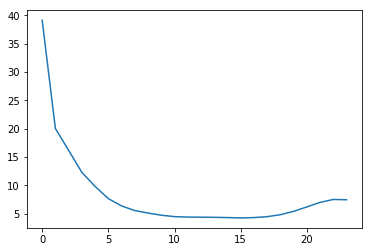

In [24]:
import matplotlib.pyplot as plt
plt.plot(distance_list)
plt.show()

In [ ]:
get_num_params(model)  # 11,683,584

#### can ALBERT do NSP?

In [1]:
import sys
sys.path.insert(0, '/anything/git/ALBERT/')

In [2]:
import tensorflow_hub as hub
import tensorflow as tf

import tensorflow as tf
import modeling
import numpy as np
import random
import modeling

from tokenization import FullTokenizer
from load_dataset import create_training_instances

/usr/local/lib/python3.5/dist-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters


In [3]:
model_nm = 'albert_large'
model_nm = 'albert_xxlarge'

In [4]:
vocab_file = '/anything/git/ALBERT/models/{}/30k-clean.vocab'.format(model_nm)
tokenizer = FullTokenizer(vocab_file=vocab_file)

spm_file = '/anything/git/ALBERT/models/{}/30k-clean.model'.format(model_nm)
tokenizer = FullTokenizer(vocab_file=None, spm_model_file=spm_file)

In [5]:
config = modeling.AlbertConfig.from_json_file('/anything/git/ALBERT/models/{}/albert_config.json'.format(model_nm))

In [6]:
max_seq_length = config.max_position_embeddings
dupe_factor = 40
short_seq_prob = 0.1
masked_lm_prob = 0.15
max_predictions_per_seq = 20
rng = random.Random(100)

In [7]:
# SOP label should be 0
sent_1 = 'How old are you?'
sent_2 = 'I am 35 years old'

# SOP label should be 1
# sent_1 = 'How old are you?'
# sent_2 = 'The Eiffel Tower is in Paris'

# SOP label should be 0
sent_1 = 'is Obama the president of the US?'
sent_2 = 'No but he was'
sent_2 = 'Do you like to play a basketball?'

In [8]:
# right order
tokens_1 = tokenizer.tokenize(sent_1)
tokens_2 = tokenizer.tokenize(sent_2)
tokens = ['[CLS]'] + tokens_1 + ['[SEP]'] + tokens_2 + ['[SEP]']
input_ids = tokenizer.convert_tokens_to_ids(tokens)
segment_ids = [0] * (len(tokens_1) + 2) + [1] * (len(tokens_2) + 1)
token_type_ids = [1] * len(segment_ids)
label = 0

In [8]:
# reverse order
tokens_1 = tokenizer.tokenize(sent_1)
tokens_2 = tokenizer.tokenize(sent_2)
tokens = ['[CLS]'] + tokens_2 + ['[SEP]'] + tokens_1 + ['[SEP]']
input_ids = tokenizer.convert_tokens_to_ids(tokens)
segment_ids = [0] * (len(tokens_2) + 2) + [1] * (len(tokens_1) + 1)
token_type_ids = [1] * len(segment_ids)
label = 1

In [9]:
print(input_ids)
print(segment_ids)
print(token_type_ids)
print(label)

[2, 25, 13, 1, 969, 540, 14, 406, 16, 14, 13, 1, 60, 3, 13, 1, 111, 42, 101, 20, 418, 21, 1652, 60, 3]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
0


In [10]:
# Already been converted from strings into ids
input_ids = tf.constant([input_ids])
segment_ids = tf.constant([segment_ids])
token_type_ids = tf.constant([token_type_ids])
input_label = tf.constant([label])

In [11]:
model = modeling.AlbertModel(config=config, is_training=False,
  input_ids=input_ids, input_mask=token_type_ids, token_type_ids=token_type_ids)

(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)


W0202 13:57:18.149680 139724942513920 deprecation.py:323] From /anything/git/ALBERT/modeling.py:253: dense (from tensorflow.python.layers.core) is deprecated and will be removed in a future version.
Instructions for updating:
Use keras.layers.Dense instead.
W0202 13:57:18.150954 139724942513920 deprecation.py:323] From /usr/local/lib/python3.5/dist-packages/tensorflow_core/python/layers/core.py:187: Layer.apply (from tensorflow.python.keras.engine.base_layer) is deprecated and will be removed in a future version.
Instructions for updating:
Please use `layer.__call__` method instead.


(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)
(1, 64, 25, 64) (1, 64, 25, 64)


In [12]:
def get_sentence_order_output(albert_config, input_tensor, labels):
    with tf.variable_scope("cls/seq_relationship"):
        output_weights = tf.get_variable(
            "output_weights",
            shape=[2, albert_config.hidden_size],
            initializer=modeling.create_initializer(
                albert_config.initializer_range))
        output_bias = tf.get_variable(
            "output_bias", shape=[2], initializer=tf.zeros_initializer())
        logits = tf.matmul(input_tensor, output_weights, transpose_b=True)
        logits = tf.nn.bias_add(logits, output_bias)
        log_probs = tf.nn.log_softmax(logits, axis=-1)
        labels = tf.reshape(labels, [-1])
        one_hot_labels = tf.one_hot(labels, depth=2, dtype=tf.float32)
        per_example_loss = -tf.reduce_sum(one_hot_labels * log_probs, axis=-1)
        loss = tf.reduce_mean(per_example_loss)
        return (loss, per_example_loss, log_probs, output_weights)

In [13]:
(sentence_order_loss, sentence_order_example_loss, sentence_order_log_probs, out_weight) = get_sentence_order_output(config, model.get_pooled_output(), input_label)

In [14]:
# Class used to save and/or restore Tensor Variables
saver = tf.train.Saver()

In [15]:
with tf.Session() as sess:
    init_op = tf.group(tf.global_variables_initializer(), tf.local_variables_initializer())
    sess.run(init_op)
    saver.restore(sess, '/anything/git/ALBERT/models/{}/model.ckpt-best'.format(model_nm))
    
    sop_loss, sop_prob, ow = sess.run([sentence_order_loss, sentence_order_log_probs, out_weight])
    pred = 0 if sop_prob[0][0] > sop_prob[0][1] else 1
    print(sop_loss, sop_prob.shape, sop_prob, np.exp(sop_prob))
    print(pred, label)

0.5137039 (1, 2) [[-0.5137039 -0.9119888]] [[0.59827554 0.4017245 ]]
0 0
